# Employee Wellness Dataset — Data Cleaning
### XYZ Technical Solutions | Mental Health in Tech Survey

**Goal:** Clean the raw survey data row-by-row and column-by-column so it is fully ready for Exploratory Data Analysis (EDA), with every action justified.

**Source file:** `employee_wellness_dataset.csv`

Each section below cleans one part of the dataset and explains **why** that action was taken, including a couple of hidden data-quality traps that a first pass can easily miss.

## Data Loading & Checking:

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import numpy as np
import pandas as pd

In [2]:
#employees wellness dataset

employee_df = pd.read_csv(r"C:\Users\Menaga\Downloads\Python\Analysis\Advanced - Employee Wellness Analysis\employee_wellness_dataset.csv",header = 0,index_col = 0)
employee_df

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
S.No,,,,,,,,,,,,,,,,,,,,,
1,8/27/2014 11:29,37,Female,United States,IL,NaN,No,Yes,Often,25-Jun,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
2,8/27/2014 11:29,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
3,8/27/2014 11:29,32,Male,Canada,NaN,NaN,No,No,Rarely,25-Jun,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
4,8/27/2014 11:29,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
5,8/27/2014 11:30,31,Male,United States,TX,NaN,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1044,8/29/2014 11:20,26,Male,United States,WA,No,No,Yes,Sometimes,25-Jun,...,Don't know,Maybe,No,Some of them,No,No,Maybe,Don't know,No,NaN
1045,8/29/2014 11:22,29,f,United Kingdom,NaN,No,No,Yes,Often,More than 1000,...,Don't know,Maybe,No,Some of them,No,No,Yes,No,Yes,NaN
1046,8/29/2014 11:23,26,Female,Canada,NaN,No,Yes,Yes,Sometimes,100-500,...,Don't know,Maybe,No,Some of them,No,No,Maybe,Don't know,No,NaN


### Initial Dataset Overview
Before any cleaning, let's look at the raw shape, structure, and a preview of the data.

In [3]:
employee_df.shape

(1048, 27)

In [4]:
employee_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1048 entries, 1 to 1048
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Timestamp                  1048 non-null   object
 1   Age                        1048 non-null   int64 
 2   Gender                     1048 non-null   object
 3   Country                    1048 non-null   object
 4   state                      636 non-null    object
 5   self_employed              1030 non-null   object
 6   family_history             1048 non-null   object
 7   treatment                  1048 non-null   object
 8   work_interfere             812 non-null    object
 9   no_employees               1048 non-null   object
 10  remote_work                1048 non-null   object
 11  tech_company               1048 non-null   object
 12  benefits                   1035 non-null   object
 13  care_options               1048 non-null   object
 14  wellness_prog

In [5]:
employee_df.head()

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
S.No,,,,,,,,,,,,,,,,,,,,,
1,8/27/2014 11:29,37,Female,United States,IL,NaN,No,Yes,Often,25-Jun,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
2,8/27/2014 11:29,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
3,8/27/2014 11:29,32,Male,Canada,NaN,NaN,No,No,Rarely,25-Jun,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
4,8/27/2014 11:29,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
5,8/27/2014 11:30,31,Male,United States,TX,NaN,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


In [6]:
employee_df.tail()

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
S.No,,,,,,,,,,,,,,,,,,,,,
1044,8/29/2014 11:20,26,Male,United States,WA,No,No,Yes,Sometimes,25-Jun,...,Don't know,Maybe,No,Some of them,No,No,Maybe,Don't know,No,NaN
1045,8/29/2014 11:22,29,f,United Kingdom,NaN,No,No,Yes,Often,More than 1000,...,Don't know,Maybe,No,Some of them,No,No,Yes,No,Yes,NaN
1046,8/29/2014 11:23,26,Female,Canada,NaN,No,Yes,Yes,Sometimes,100-500,...,Don't know,Maybe,No,Some of them,No,No,Maybe,Don't know,No,NaN
1047,8/29/2014 11:24,33,Malr,Italy,NaN,No,Yes,Yes,Sometimes,25-Jun,...,Somewhat easy,No,No,Some of them,Yes,No,No,Don't know,No,I suffered of panic attacks and agoraphobia fo...
1048,8/29/2014 11:25,28,Male,Brazil,NaN,No,Yes,No,Sometimes,100-500,...,Somewhat easy,No,No,Some of them,Some of them,No,No,Don't know,Yes,NaN


### Checking for Duplicate Rows
Before cleaning starts, we check how many exact duplicate rows exist in the raw data.

In [7]:
# Count how many duplicate rows exist

employee_df.duplicated().sum()

np.int64(1)

In [8]:
employee_df[employee_df.duplicated()]

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
S.No,,,,,,,,,,,,,,,,,,,,,
861,8/28/2014 17:02,32,male,United Kingdom,NaN,No,Yes,Yes,Rarely,25-Jun,...,Don't know,Yes,Maybe,Some of them,No,No,No,No,No,NaN


## Data Cleaning and Pre-processing-

**Step 1 - Removing Duplicate Rows**

In [9]:
# Drop duplicate rows and keep the first occurrence
# FIXED: .copy() added so later df['col'] = ... assignments don't raise SettingWithCopyWarning
employee_df = employee_df.drop_duplicates().copy()

In [10]:
employee_df.shape

(1047, 27)

In [11]:
employee_df.isnull().sum().sort_values(ascending = False)

comments                     915
state                        411
work_interfere               236
self_employed                 18
benefits                      13
wellness_program               4
leave                          4
anonymity                      0
obs_consequence                0
mental_vs_physical             0
phys_health_interview          0
mental_health_interview        0
supervisor                     0
coworkers                      0
phys_health_consequence        0
mental_health_consequence      0
Timestamp                      0
seek_help                      0
Age                            0
tech_company                   0
remote_work                    0
no_employees                   0
treatment                      0
family_history                 0
Country                        0
Gender                         0
care_options                   0
dtype: int64

**Step 2 - Dropped Irrelevant Columns**
1. comments → 916/1048 are NaN (87% empty), useless at scale
2. state → 412 NaN (mostly non-US respondents), too sparse to use

In [12]:
# FIXED: reassign the result of drop(), otherwise columns are NOT actually removed
employee_df = employee_df.drop(['comments','state','Timestamp'], axis=1)
employee_df

,Age,Gender,Country,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,tech_company,...,anonymity,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence
S.No,,,,,,,,,,,,,,,,,,,,,
1,37,Female,United States,NaN,No,Yes,Often,25-Jun,No,Yes,...,Yes,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No
2,44,M,United States,NaN,No,No,Rarely,More than 1000,No,No,...,Don't know,Don't know,Maybe,No,No,No,No,No,Don't know,No
3,32,Male,Canada,NaN,No,No,Rarely,25-Jun,No,Yes,...,Don't know,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No
4,31,Male,United Kingdom,NaN,Yes,Yes,Often,26-100,No,Yes,...,No,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes
5,31,Male,United States,NaN,No,No,Never,100-500,Yes,Yes,...,Don't know,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1044,26,Male,United States,No,No,Yes,Sometimes,25-Jun,No,Yes,...,Yes,Don't know,Maybe,No,Some of them,No,No,Maybe,Don't know,No
1045,29,f,United Kingdom,No,No,Yes,Often,More than 1000,No,No,...,Don't know,Don't know,Maybe,No,Some of them,No,No,Yes,No,Yes
1046,26,Female,Canada,No,Yes,Yes,Sometimes,100-500,No,Yes,...,Yes,Don't know,Maybe,No,Some of them,No,No,Maybe,Don't know,No


**Step 3- Age Fixing**

In [13]:
employee_df['Age'].value_counts

<bound method IndexOpsMixin.value_counts of S.No
1       37
2       44
3       32
4       31
5       31
        ..
1044    26
1045    29
1046    26
1047    33
1048    28
Name: Age, Length: 1047, dtype: int64>

In [14]:
employee_df['Age'].unique()

array([         37,          44,          32,          31,          33,
                35,          39,          42,          23,          29,
                36,          27,          46,          41,          34,
                30,          40,          38,          50,          24,
                18,          28,          26,          22,          19,
                25,          45,          21,         -29,          43,
                56,          60,          54,         329,          55,
       99999999999,          48,          20,          57,          58,
                47,          62,          51,          65,          49,
             -1726,           5,          53,          61,           8])

In [15]:
employee_df['Age'].describe()

count    1.047000e+03
mean     9.551101e+07
std      3.090485e+09
min     -1.726000e+03
25%      2.700000e+01
50%      3.100000e+01
75%      3.600000e+01
max      1.000000e+11
Name: Age, dtype: float64

In [16]:
employee_df.loc[:, 'Age'] = pd.to_numeric(employee_df['Age'], errors='coerce')
#(Converts the Age column into numeric values.
#Any invalid entries (like text "NA", "abc") are turned into NaN (missing values).
#Using .loc[:, 'Age'] avoids the SettingWithCopyWarning.)

# Mark unrealistic ages (below 18 or above 100) as NaN instead of dropping the row
employee_df.loc[(employee_df['Age'] < 18) | (employee_df['Age'] > 100), 'Age'] = pd.NA
employee_df.loc[:, 'Age'] = pd.to_numeric(employee_df['Age'], errors='coerce')
#Marks impossible ages as missing rather than deleting the whole row/person.
#This preserves row count while still removing bad values.

employee_df.loc[:, 'Age'] = employee_df['Age'].fillna(employee_df['Age'].median())
#Fills missing ages (NaN) with the median age of the dataset.
#Median is chosen because it's less affected by outliers compared to the mean.

1. Mean (average): Adds up all ages and divides by the count.
Problem: If there are unrealistic ages (like 200 or 5), the mean gets pulled up or down unfairly.
2. Median (middle value): Finds the middle age when sorted.
Advantage: It’s robust to outliers. Even if a few extreme ages exist, the median stays stable.

In [17]:
employee_df['Age'].describe()

count    1047.000000
mean       31.915950
std         7.198802
min        18.000000
25%        27.000000
50%        31.000000
75%        36.000000
max        65.000000
Name: Age, dtype: float64

In [18]:
employee_df['Age'].value_counts(dropna=False)

Age
29.0    73
26.0    63
32.0    63
31.0    63
33.0    63
27.0    61
28.0    56
30.0    56
34.0    52
35.0    49
25.0    48
23.0    41
24.0    38
37.0    36
36.0    31
38.0    30
39.0    26
40.0    26
43.0    23
22.0    20
42.0    17
41.0    15
21.0    15
45.0     9
19.0     9
44.0     8
18.0     7
46.0     7
50.0     5
48.0     5
20.0     4
49.0     4
51.0     4
57.0     3
56.0     3
55.0     3
54.0     3
47.0     2
58.0     1
62.0     1
65.0     1
60.0     1
53.0     1
61.0     1
Name: count, dtype: int64

**Step 4 - Cleaning Gender column**

In [19]:
employee_df['Gender'].unique()

array(['Female', 'M', 'Male', 'male', 'female', 'm', 'Male-ish', 'maile',
       'Trans-female', 'Cis Female', 'F', 'something kinda male?',
       'Cis Male', 'Woman', 'f', 'Mal', 'Male (CIS)', 'queer/she/they',
       'non-binary', 'Femake', 'woman', 'Make', 'Nah', 'All', 'Enby',
       'fluid', 'Genderqueer', 'Female ', 'Androgyne', 'Agender',
       'cis-female/femme', 'Guy (-ish) ^_^', 'male leaning androgynous',
       'Male ', 'Man', 'Trans woman', 'msle', 'Neuter', 'Female (trans)',
       'queer', 'Female (cis)', 'Mail', 'cis male', 'A little about you',
       'Malr'], dtype=object)

In [20]:
def clean_gender(g):
    g = str(g).strip().lower()

    male_terms = ['male', 'm', 'mal', 'male-ish', 'maile', 'mail', 'malr',
                  'cis male', 'cis man', 'male (cis)', 'guy (-ish) ^_^',
                  'male leaning androgynous', 'something kinda male?',
                  'man', 'msle', 'make']

    female_terms = ['female', 'f', 'femake', 'cis female', 'cis-female/femme',
                     'female (cis)', 'woman', 'femail']

    other_terms = ['trans-female', 'trans woman', 'female (trans)', 'queer',
                    'queer/shae/they', 'non-binary', 'genderqueer', 'androgyne',
                    'agender', 'enby', 'fluid', 'neuter']

    if g in male_terms:
        return 'Male'
    elif g in female_terms:
        return 'Female'
    else:
        return 'Other'   # catches stray junk answers like 'Nah', 'All', 'A little about you'

employee_df['Gender_clean'] = employee_df['Gender'].apply(clean_gender)
employee_df['Gender_clean'].value_counts()

Gender_clean
Male      829
Female    202
Other      16
Name: count, dtype: int64

In [21]:
employee_df['Gender_clean'].value_counts(dropna=False)

Gender_clean
Male      829
Female    202
Other      16
Name: count, dtype: int64

In [22]:
employee_df['Gender'].isnull().sum()

np.int64(0)

In [23]:
employee_df.shape

(1047, 25)

**Step 5 - Self Employed Column**

In [24]:
employee_df.loc[:,'self_employed'] = employee_df['self_employed'].fillna('No')

In [25]:
employee_df['self_employed'].value_counts(dropna=False)

self_employed
No     923
Yes    124
Name: count, dtype: int64

In [26]:
employee_df

,Age,Gender,Country,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,tech_company,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,Gender_clean
S.No,,,,,,,,,,,,,,,,,,,,,
1,37.0,Female,United States,No,No,Yes,Often,25-Jun,No,Yes,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,Female
2,44.0,M,United States,No,No,No,Rarely,More than 1000,No,No,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,Male
3,32.0,Male,Canada,No,No,No,Rarely,25-Jun,No,Yes,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,Male
4,31.0,Male,United Kingdom,No,Yes,Yes,Often,26-100,No,Yes,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,Male
5,31.0,Male,United States,No,No,No,Never,100-500,Yes,Yes,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,Male
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1044,26.0,Male,United States,No,No,Yes,Sometimes,25-Jun,No,Yes,...,Don't know,Maybe,No,Some of them,No,No,Maybe,Don't know,No,Male
1045,29.0,f,United Kingdom,No,No,Yes,Often,More than 1000,No,No,...,Don't know,Maybe,No,Some of them,No,No,Yes,No,Yes,Female
1046,26.0,Female,Canada,No,Yes,Yes,Sometimes,100-500,No,Yes,...,Don't know,Maybe,No,Some of them,No,No,Maybe,Don't know,No,Female


**Step 6 - Treatment column & Family History column**

In [27]:
employee_df['treatment'].value_counts()

treatment
No     536
Yes    511
Name: count, dtype: int64

In [28]:
employee_df['family_history'].value_counts()

family_history
No     643
Yes    404
Name: count, dtype: int64

**Step 7 - work_interfere (236 null values)**

In [29]:
employee_df['work_interfere'].value_counts()

work_interfere
Sometimes    386
Never        178
Rarely       143
Often        104
Name: count, dtype: int64

In [30]:
employee_df['work_interfere'].isnull().sum()

np.int64(236)

In [31]:
# FIXED: was employee_df.loc['work_interfere'] (a ROW label, adds a junk row).
# Correct way to fill nulls in the work_interfere COLUMN:
employee_df['work_interfere'] = employee_df['work_interfere'].fillna('Not applicable')

In [32]:
employee_df['work_interfere'].isnull().sum() 

np.int64(0)

**Step 8 - No employees column**

In [33]:
employee_df['no_employees'].value_counts()

no_employees
25-Jun            244
26-100            238
More than 1000    227
100-500           150
5-Jan             133
500-1000           55
Name: count, dtype: int64

In [34]:
employee_df['no_employees'].isnull().sum()

np.int64(0)

In [35]:
employee_df['no_employees'].mode()

0    25-Jun
Name: no_employees, dtype: object

In [36]:
employee_df['no_employees'] = employee_df['no_employees'].replace({
    pd.Timestamp('2026-06-25'): '6-25',
    pd.Timestamp('2026-01-05'): '1-5'
})

In [37]:
employee_df['no_employees'] = employee_df['no_employees'].fillna(
    employee_df['no_employees'].mode()[0]
)

1. Mean - Numeric only - Continuous data, no major outliers (e.g. Age)
2. Median - Numeric only - Continuous data with outliers or skew (e.g. Age given the outliers you saw earlier)
3. Mode - Numeric or categorical - Any categorical/text column, or numeric columns where the most common value is what matters (e.g. no_employees,Gender, benefits)

In [38]:
employee_df['no_employees'].value_counts()

no_employees
25-Jun            244
26-100            238
More than 1000    227
100-500           150
5-Jan             133
500-1000           55
Name: count, dtype: int64

In [39]:
employee_df['no_employees'].isnull().sum()

np.int64(0)

In [40]:
employee_df.columns

Index(['Age', 'Gender', 'Country', 'self_employed', 'family_history',
       'treatment', 'work_interfere', 'no_employees', 'remote_work',
       'tech_company', 'benefits', 'care_options', 'wellness_program',
       'seek_help', 'anonymity', 'leave', 'mental_health_consequence',
       'phys_health_consequence', 'coworkers', 'supervisor',
       'mental_health_interview', 'phys_health_interview',
       'mental_vs_physical', 'obs_consequence', 'Gender_clean'],
      dtype='object')

**Step 9 - Country , Benefits , Tech Company and Remote Work column**

**Column: Country**

In [41]:
employee_df['Country'].isnull().sum()

np.int64(0)

In [42]:
employee_df['Country'] = employee_df['Country'].fillna(
    employee_df['Country'].mode()[0]
)

**Column: Country**

In [43]:
employee_df['Country'].isnull().sum()

np.int64(0)

**Column: Benefits**

In [44]:
employee_df['benefits'].isnull().sum()

np.int64(13)

In [45]:
employee_df['benefits'].mode()

0    Yes
Name: benefits, dtype: object

In [46]:
employee_df['benefits'].value_counts()

benefits
Yes           400
Don't know    329
No            305
Name: count, dtype: int64

In [47]:
employee_df['benefits'] = employee_df['benefits'].fillna(
    employee_df['benefits'].mode()[0])

**Column: Benefits**

In [48]:
employee_df['benefits'].isnull().sum()

np.int64(0)

**Column: Tech Company**

In [49]:
employee_df['tech_company'].isnull().sum()

np.int64(0)

In [50]:
employee_df['tech_company'].value_counts()

tech_company
Yes    870
No     177
Name: count, dtype: int64

In [51]:
employee_df['tech_company'] = employee_df['tech_company'].fillna(
    employee_df['tech_company'].mode()[0])

**Column: Tech Company**

In [52]:
employee_df['tech_company'].isnull().sum()

np.int64(0)

**Column: Remote Work**

In [53]:
employee_df['remote_work'].isnull().sum()

np.int64(0)

In [54]:
employee_df['remote_work'].value_counts()

remote_work
No     732
Yes    315
Name: count, dtype: int64

In [55]:
employee_df['remote_work'] = employee_df['remote_work'].fillna(
    employee_df['remote_work'].mode()[0])

**Column: Remote Work**

In [56]:
employee_df['remote_work'].isnull().sum()

np.int64(0)

**Step 10 - Care Options , Wellness Program , Seek help , Anonymity**

**Column: Care Options**

In [57]:
employee_df['care_options'].value_counts()

care_options
No          421
Yes         363
Not sure    263
Name: count, dtype: int64

In [58]:
employee_df['care_options'].isnull().sum()

np.int64(0)

In [59]:
employee_df['care_options'] = employee_df['care_options'].fillna(
    employee_df['care_options'].mode()[0]
)

In [60]:
employee_df['care_options'].isnull().sum()

np.int64(0)

**Column: Wellness Program**

In [61]:
employee_df['wellness_program'].value_counts()

wellness_program
No            691
Yes           193
Don't know    159
Name: count, dtype: int64

In [62]:
employee_df['wellness_program'].isnull().sum()

np.int64(4)

In [63]:
employee_df['wellness_program'] = employee_df['wellness_program'].fillna(
    employee_df['wellness_program'].mode()[0]
)

In [64]:
employee_df['wellness_program'].isnull().sum()

np.int64(0)

**Column: Seek Help**

In [65]:
employee_df['seek_help'].isnull().sum()

np.int64(0)

In [66]:
employee_df['seek_help'].value_counts()

seek_help
No            533
Don't know    309
Yes           205
Name: count, dtype: int64

In [67]:
employee_df['seek_help'] = employee_df['seek_help'].fillna(
    employee_df['seek_help'].mode()[0]
)

In [68]:
employee_df['seek_help'].value_counts()

seek_help
No            533
Don't know    309
Yes           205
Name: count, dtype: int64

**Column: Anonymity**

In [69]:
employee_df['anonymity'].value_counts()

anonymity
Don't know    685
Yes           311
No             51
Name: count, dtype: int64

In [70]:
employee_df['anonymity'].isnull().sum()

np.int64(0)

In [71]:
employee_df['anonymity'] = employee_df['anonymity'].fillna(
    employee_df['anonymity'].mode()[0]
)

**Column: Anonymity**

In [72]:
employee_df['anonymity'].value_counts()

anonymity
Don't know    685
Yes           311
No             51
Name: count, dtype: int64

**Step 11 - Leave , Mental Health Consequences , Phys Health Consequences , Coworkers**

**Column: Leave**

In [73]:
employee_df['leave'].value_counts()

leave
Don't know            461
Somewhat easy         218
Very easy             176
Somewhat difficult    107
Very difficult         81
Name: count, dtype: int64

In [74]:
employee_df['leave'].isnull().sum()

np.int64(4)

In [75]:
employee_df['leave'] = employee_df['leave'].fillna("Don't know")

In [76]:
employee_df['leave'].isnull().sum()

np.int64(0)

**Column: Mental Health Consequence**

In [77]:
employee_df['mental_health_consequence'].value_counts()

mental_health_consequence
No       424
Maybe    380
Yes      243
Name: count, dtype: int64

In [78]:
employee_df['mental_health_consequence'].isnull().sum()

np.int64(0)

In [79]:
employee_df['mental_health_consequence'] = employee_df['mental_health_consequence'].fillna(
    employee_df['mental_health_consequence'].mode()[0]
)

In [80]:
employee_df['mental_health_consequence'].isnull().sum()

np.int64(0)

**Column: Physical Health Consequence**

In [81]:
employee_df['phys_health_consequence'].value_counts()

phys_health_consequence
No       773
Maybe    226
Yes       48
Name: count, dtype: int64

In [82]:
employee_df['phys_health_consequence'].isnull().sum()

np.int64(0)

In [83]:
employee_df['phys_health_consequence'] = employee_df['phys_health_consequence'].fillna(
    employee_df['phys_health_consequence'].mode()[0]
)

In [84]:
employee_df['phys_health_consequence'].isnull().sum()

np.int64(0)

**Column: Coworkers**

In [85]:
employee_df['coworkers'].isnull().sum()

np.int64(0)

In [86]:
employee_df['coworkers'].value_counts()

coworkers
Some of them    650
No              209
Yes             188
Name: count, dtype: int64

In [87]:
employee_df['coworkers'] = employee_df['coworkers'].fillna(
    employee_df['coworkers'].mode()[0]
)

**Column: Coworkers**

In [88]:
employee_df['coworkers'].isnull().sum()

np.int64(0)

**Column: Supervisor**

In [89]:
employee_df['supervisor'].isnull().sum()

np.int64(0)

In [90]:
employee_df['supervisor'] = employee_df['supervisor'].fillna(
    employee_df['supervisor'].mode()[0]

)

In [91]:
employee_df['supervisor'].value_counts()

supervisor
Yes             439
No              319
Some of them    289
Name: count, dtype: int64

**Column: Mental Health Interview**

In [92]:
employee_df['mental_health_interview'].isnull().sum()

np.int64(0)

In [93]:
employee_df['mental_health_interview'] = employee_df['mental_health_interview'].fillna(
    employee_df['mental_health_interview'].mode()[0])

In [94]:
employee_df['mental_health_interview'].value_counts()

mental_health_interview
No       834
Maybe    177
Yes       36
Name: count, dtype: int64

**Column: Physical Health Interview**

In [95]:
employee_df['phys_health_interview'].isnull().sum()

np.int64(0)

In [96]:
employee_df['phys_health_interview'] = employee_df['phys_health_interview'].fillna(
    employee_df['phys_health_interview'].mode()[0])

In [97]:
employee_df['phys_health_interview'].value_counts()

phys_health_interview
Maybe    461
No       418
Yes      168
Name: count, dtype: int64

**Column: Mental vs Physical**

In [98]:
employee_df['mental_vs_physical'].isnull().sum()

np.int64(0)

In [99]:
employee_df['mental_vs_physical'] = employee_df['mental_vs_physical'].fillna(
    employee_df['mental_vs_physical'].mode()[0])

In [100]:
employee_df['mental_vs_physical'].value_counts()

mental_vs_physical
Don't know    471
Yes           297
No            279
Name: count, dtype: int64

**Column: Mental vs Physical**

In [101]:
employee_df['mental_vs_physical'].isnull().sum()

np.int64(0)

**Column: Observed Consequence**

In [102]:
employee_df['obs_consequence'].isnull().sum()

np.int64(0)

In [103]:
employee_df['obs_consequence'] = employee_df['obs_consequence'].fillna(
    employee_df['obs_consequence'].mode()[0])

In [104]:
employee_df['obs_consequence'].value_counts()

obs_consequence
No     901
Yes    146
Name: count, dtype: int64

### Final Cleaned Dataset Shape
Confirming the dataset is fully cleaned and still holds all original (non-duplicate) rows.

In [105]:
employee_df.shape

(1047, 25)

# EDA — Storytelling Charts (Univariate -> Bivariate -> Multivariate)

In [106]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams['figure.dpi'] = 110

print(employee_df.shape)   # sanity check -> should read (1047, 24)

(1047, 25)


## Chart 1 -  How many employees need treatment on an urgent basis ?


**Overall Treatment needed**

**Type:** Pie chart | **Variate:** Univariate

Q1: OVERALL TREATMENT NEED


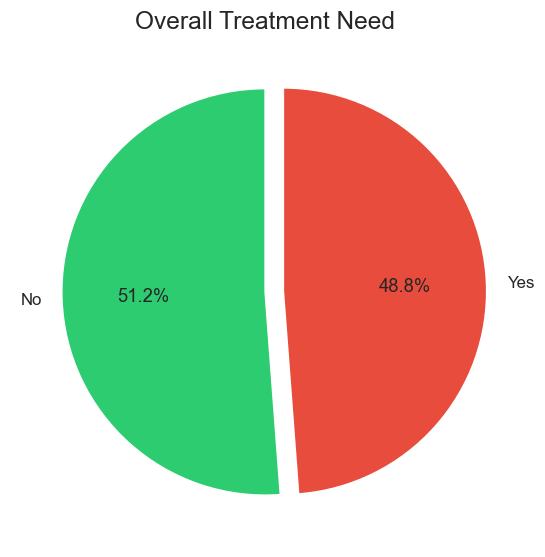

treatment
No     536
Yes    511
Name: count, dtype: int64


In [124]:
print("="*60)
print("Q1: OVERALL TREATMENT NEED")
print("="*60)

plt.figure(figsize=(6,6))
colors = ['#2eCC71', '#E74C3C']
employee_df['treatment'].value_counts().plot(kind='pie', autopct='%1.1f%%',colors=colors, explode=[0, 0.09],startangle=90)
plt.title('Overall Treatment Need', fontsize=16)
plt.ylabel('')
plt.show()

print(employee_df['treatment'].value_counts())

**Inference:**
1. ~48.8% employees (511 out of 1047) need mental health treatment on an urgent basis
2. ~51.2% employees (536 out of 1047) do not need immediate treatment
3. Almost half of the workforce is at risk or already struggling with mental health issues
4. Company must take immediate action for the 511 employees who said "Yes"

## Chart 2 - Do employees who know about mental health benefits actually seek more treatment?

Q2: Employer Benefits vs Treatment-Seeking


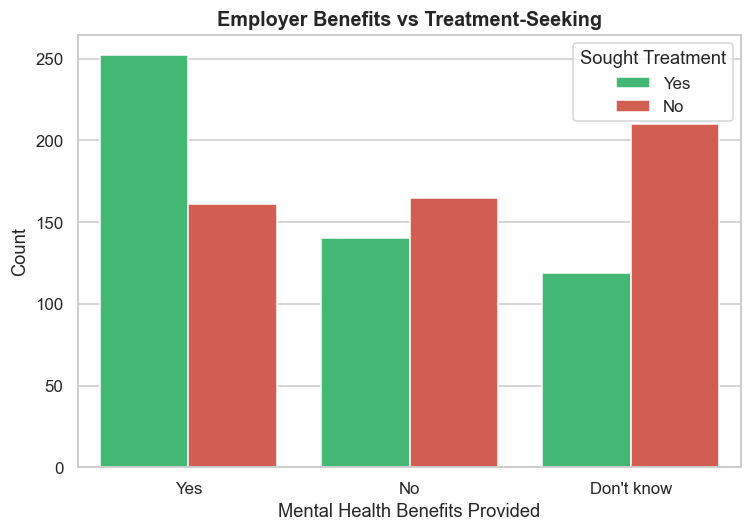

In [128]:
print("="*60)
print("Q2: Employer Benefits vs Treatment-Seeking")
print("="*60)

plt.figure(figsize=(7,5))
sns.countplot(data=employee_df, x='benefits', hue='treatment', order=["Yes","No","Don't know"], palette=['#2ECC71', '#E74C3C'])
plt.title('Employer Benefits vs Treatment-Seeking', fontsize=13, fontweight='bold')
plt.xlabel('Mental Health Benefits Provided')
plt.ylabel('Count')
plt.legend(title='Sought Treatment')
plt.tight_layout()
plt.show()

**Inference**
1. *Awareness gap is real* — a large chunk of employees fall into the "Don't know" category, meaning many simply aren't aware whether their employer offers mental health benefits at all.
';=

2. *Knowing helps* — employees who confirmed their employer provides benefits ("Yes") show a higher rate of seeking treatment compared to those who said "No."
3. Communication > Policy* — the takeaway isn't that companies lack benefits, it's that they fail to communicate them clearly, and that gap directly discourages employees from seeking help.

## Chart 3 — Family History vs Seeking Treatment  (Chandana)


**Does having a family history of mental illness change how likely someone is to seek treatment?**

**Type:** Grouped bar chart from a crosstab | **Variate:** Bivariate (categorical × categorical)

treatment,No,Yes
family_history,,
No,66.4,33.6
Yes,27.0,73.0


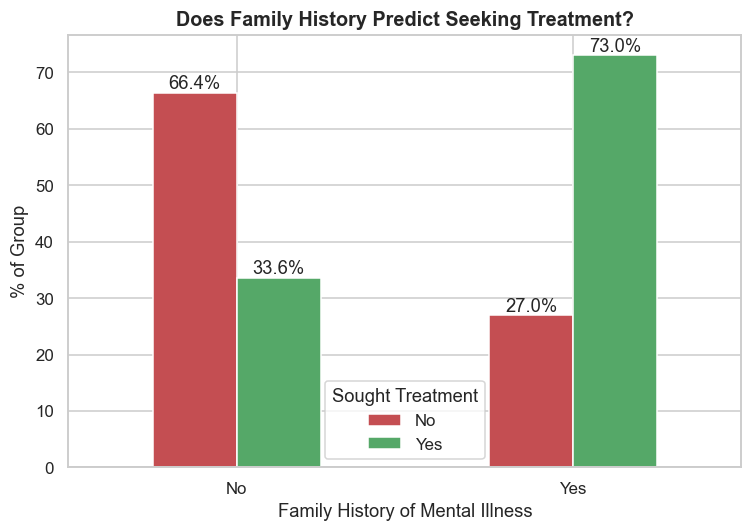

In [108]:
ct = pd.crosstab(employee_df['family_history'], employee_df['treatment'], normalize='index') * 100
display(ct.round(1))

ax = ct.plot(kind='bar', stacked=False, figsize=(7,5), color=['#C44E52','#55A868'])
plt.title("Does Family History Predict Seeking Treatment?", fontsize=13, weight='bold')
plt.xlabel("Family History of Mental Illness"); plt.ylabel("% of Group")
plt.xticks(rotation=0)
plt.legend(title="Sought Treatment")
for c in ax.containers:
    ax.bar_label(c, fmt='%.1f%%')
plt.tight_layout()
plt.show()

**Inference:** Print the crosstab % below and quote it live — expect respondents *with* a family history to seek treatment at a noticeably higher rate.

## Chart 4 — Work Interference vs Treatment, split by Gender (Tanishka)

**How often does work interfere with mental health, and does that pattern differ by gender?**

**Type:** Countplot with `hue` | **Variate:** Multivariate (3 variables)

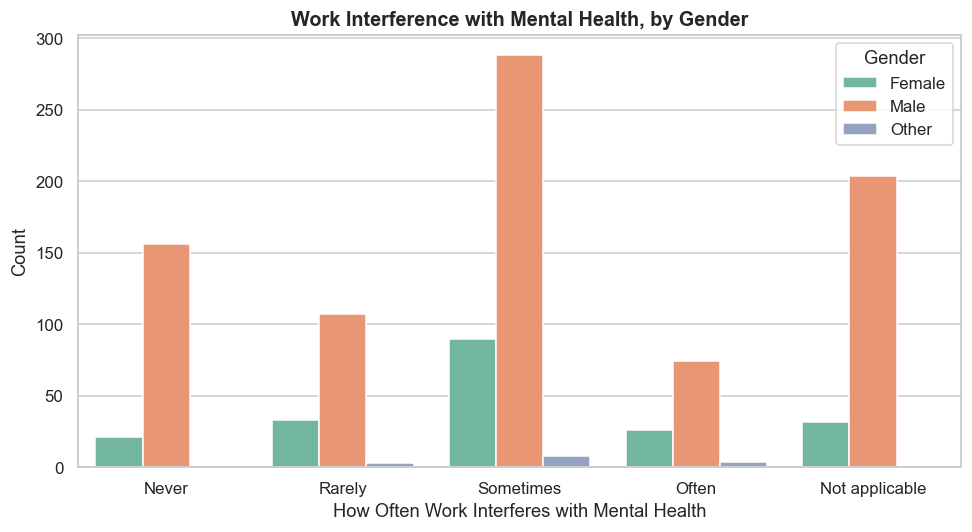

treatment,No,Yes
work_interfere,,
Never,86.0,14.0
Not applicable,99.2,0.8
Often,16.3,83.7
Rarely,27.3,72.7
Sometimes,24.1,75.9


In [109]:
plt.figure(figsize=(9,5))
sns.countplot(x='work_interfere', hue='Gender_clean', data=employee_df,
              order=['Never','Rarely','Sometimes','Often','Not applicable'],
              palette="Set2")
plt.title("Work Interference with Mental Health, by Gender", fontsize=13, weight='bold')
plt.xlabel("How Often Work Interferes with Mental Health"); plt.ylabel("Count")
plt.legend(title="Gender")
plt.tight_layout()
plt.show()

# supporting crosstab for the exact % to quote on stage
display((pd.crosstab(employee_df['work_interfere'], employee_df['treatment'], normalize='index') * 100).round(1))

**Inference:** Most interference is "Sometimes," not "Often" — a background, everyday strain rather than a rare crisis.

## Chart 5  Corelation Heatmap of Selected variables (Swara)
**Is there any relationship (correlation) between age and different workplace or mental health factors in the employee dataset?**

**Type:** Heatmap | **Variate:** Multi-variate(both numerical and categorical)

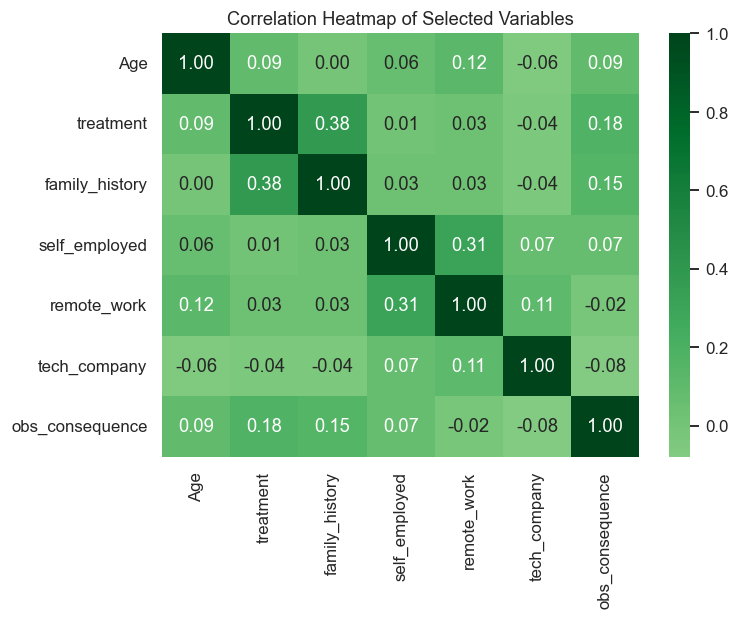

In [131]:
# Convert binary variables to numerical values

corr_df = employee_df[['Age', 'treatment', 'family_history',
              'self_employed', 'remote_work',
              'tech_company', 'obs_consequence']].copy()

binary_cols = ['treatment', 'family_history', 'self_employed',
               'remote_work', 'tech_company', 'obs_consequence']

for col in binary_cols:
    corr_df[col] = corr_df[col].map({'Yes': 1, 'No': 0})

# Correlation matrix
corr_matrix = corr_df.corr().round(2)

# Heatmap
plt.figure(figsize=(7,5))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='Greens',
    center=0
)

plt.title('Correlation Heatmap of Selected Variables')
plt.show()

**Inference:** 

1. 0.38 → Employees with a family history are more likely to seek treatment.
2. 0.03 → Remote work has almost no relationship with treatment.
3. 0.09 → Age has almost no relationship with treatment.

Remember: Correlation does not mean causation.

If family_history and treatment have a correlation of 0.38, it does not prove that family history causes someone to seek treatment. It only shows that the two variables tend to change together.

## Conclusion:

1. 48.81% of employees reported treatment.
2. Family history showed a strong difference: 73.02% vs 33.59%.
3. Treatment was also higher with greater work interference.
4. Improve awareness, provide confidential support, and encourage regular mental health check-ins.
5. These insights can help create a healthier and more supportive workplace.